In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from scipy.stats import pearsonr, mannwhitneyu, ttest_ind

# All analysis for Likert Data

In [33]:
df = pd.read_csv("cleaned_data_explanations_gold.csv", index_col=0)
df.dropna(
    subset=["cleverness", "uncommonness", "remoteness", "originality", "explanation"],
    inplace=True,
)
df = df.loc[
    (df["education"] != "Technical / community college")
    & (df["education"] != "High school diploma")
]
df.reset_index(inplace=True)
df

,prolific_ID,cleverness,uncommonness,remoteness,originality,explanation,problem,condition,education,response,response_id,problem_id,originality_rescaled_factor,effectiveness_rescaled_factor,word_count,duplicate_flag,ai_generated_flag,two_sentence_flag
0,66a280c10221d728f1f23b30,4,3,1,4,I think this idea implements gamification and ...,assist people with learning impairments retain...,oracle,Undergraduate degree (BA / BSc / Other),"a flash card lock screen widget, you can only ...",10,1,4.1,5.0,18,0,0,0
1,672ede539bd39a8deecc501d,5,5,5,5,A very net idea to help give people a challeng...,assist people with learning impairments retain...,oracle,Undergraduate degree (BA / BSc / Other),"a flash card lock screen widget, you can only ...",10,1,4.1,5.0,18,0,0,0
2,677e915bcc73ee3be3437299,5,5,4,5,So far the most original response. I have yet ...,assist people with learning impairments retain...,no_oracle,Graduate degree (MA / MSc / Other),"a flash card lock screen widget, you can only ...",10,1,4.1,5.0,18,0,0,0
3,677f3264cb1352b3b3ba903d,4,4,4,4,I have no experience in the world of psycholog...,assist people with learning impairments retain...,oracle,Undergraduate degree (BA / BSc / Other),"a flash card lock screen widget, you can only ...",10,1,4.1,5.0,18,0,0,0
4,677be0d10517e13e6c1e47b8,5,1,5,5,This helps prevent overwhelm and makes retenti...,assist people with learning impairments retain...,oracle,Undergraduate degree (BA / BSc / Other),aloow them to see as many as pictures in their...,368,1,2.7,3.2,14,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,674b3b45f390921a88f24747,1,1,1,1,This is a generic response that could be appli...,reduce the environmental impact of air travel,no_oracle,Undergraduate degree (BA / BSc / Other),use other alternatives to flight,7058,14,3.0,3.2,5,0,0,0
826,675c9d0a538d1eb89a70c8fa,2,2,2,2,Other alternatives to flights are considered b...,reduce the environmental impact of air travel,no_oracle,Undergraduate degree (BA / BSc / Other),use other alternatives to flight,7058,14,3.0,3.2,5,0,0,0
827,675d76579bfdc8e08fc58374,4,5,4,2,Alternatives to flight is the most common way ...,reduce the environmental impact of air travel,no_oracle,Undergraduate degree (BA / BSc / Other),use other alternatives to flight,7058,14,3.0,3.2,5,0,0,0
828,60ff1d21180a0ea603111a24,4,2,3,3,I rated very unoriginal because this is a solu...,reduce the environmental impact of air travel,no_oracle,Graduate degree (MA / MSc / Other),using fuel that is pure,7173,14,2.1,2.3,5,0,0,0


In [12]:
# check for differences in ed level
df.groupby("condition")["education"].value_counts(normalize=True)

condition  education                              
no_oracle  Undergraduate degree (BA / BSc / Other)    0.637255
           Graduate degree (MA / MSc / Other)         0.362745
oracle     Undergraduate degree (BA / BSc / Other)    0.594787
           Graduate degree (MA / MSc / Other)         0.376777
           Doctorate degree (PhD / Other)             0.028436
Name: proportion, dtype: float64

## Pairwise no-oracle correlations

In [34]:
# cleaned
df_no_oracle = df.loc[df["condition"] != "oracle"]
print(pearsonr(df_no_oracle["cleverness"], df_no_oracle["remoteness"]))
print(pearsonr(df_no_oracle["cleverness"], df_no_oracle["uncommonness"]))
print(pearsonr(df_no_oracle["remoteness"], df_no_oracle["uncommonness"]))

PearsonRResult(statistic=0.4687728974950346, pvalue=1.11282163651922e-23)
PearsonRResult(statistic=0.4466948545576943, pvalue=2.0969219461154734e-21)
PearsonRResult(statistic=0.6695752660490417, pvalue=2.1431669289049238e-54)


In [26]:
# cleaned
print(pearsonr(df_no_oracle["originality"], df_no_oracle["cleverness"]))
print(pearsonr(df_no_oracle["originality"], df_no_oracle["remoteness"]))
print(pearsonr(df_no_oracle["originality"], df_no_oracle["uncommonness"]))

PearsonRResult(statistic=0.6038616189583397, pvalue=6.70566237160212e-42)
PearsonRResult(statistic=0.623340203765098, pvalue=2.703111426736663e-45)
PearsonRResult(statistic=0.6531161095795986, pvalue=5.674925161144033e-51)


## Pairwise oracle correlations

In [35]:
# cleaned
df_oracle = df.loc[df["condition"] == "oracle"]
print(pearsonr(df_oracle["cleverness"], df_oracle["remoteness"]))
print(pearsonr(df_oracle["cleverness"], df_oracle["uncommonness"]))
print(pearsonr(df_oracle["remoteness"], df_oracle["uncommonness"]))

PearsonRResult(statistic=0.5906997958983242, pvalue=4.776718328824764e-41)
PearsonRResult(statistic=0.4701293233937549, pvalue=1.3634033153806951e-24)
PearsonRResult(statistic=0.437975473789118, pvalue=3.3173460475474224e-21)


In [25]:
# cleaned
print(pearsonr(df_oracle["originality"], df_oracle["cleverness"]))
print(pearsonr(df_oracle["originality"], df_oracle["remoteness"]))
print(pearsonr(df_oracle["originality"], df_oracle["uncommonness"]))

PearsonRResult(statistic=0.6483456684969005, pvalue=1.0998605282033233e-51)
PearsonRResult(statistic=0.4661947523260691, pvalue=3.702575556854885e-24)
PearsonRResult(statistic=0.5135119973691412, pvalue=9.096179253133304e-30)


In [17]:
# summary stats per condition
df_oracle[["cleverness", "remoteness", "uncommonness", "originality"]].describe()

,cleverness,remoteness,uncommonness,originality
count,422.000000,422.000000,422.000000,422.000000
mean,2.829384,2.419431,2.464455,2.623223
std,1.452098,1.271617,1.372418,1.425166
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000
50%,3.000000,2.000000,2.000000,2.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [32]:
df_oracle[["cleverness", "remoteness", "uncommonness", "originality"]].var()

cleverness      2.108588
remoteness      1.617009
uncommonness    1.883532
originality     2.031098
dtype: float64

In [19]:
df_no_oracle[["cleverness", "remoteness", "uncommonness", "originality"]].describe()

,cleverness,remoteness,uncommonness,originality
count,408.000000,408.000000,408.000000,408.000000
mean,2.992647,2.448529,2.455882,2.639706
std,1.338320,1.282005,1.312579,1.355702
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000
50%,3.000000,2.000000,2.000000,2.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [33]:
df_no_oracle[["cleverness", "remoteness", "uncommonness", "originality"]].var()

cleverness      1.791101
remoteness      1.643536
uncommonness    1.722865
originality     1.837928
dtype: float64

## Check for differences in each facet score as a function of condition

In [27]:
# are oracle and no oracle originality scores drawn from the same distribution?
mannwhitneyu(
    df_oracle["originality"], df_no_oracle["originality"], alternative="two-sided"
)

MannwhitneyuResult(statistic=85030.0, pvalue=0.7531533469713373)

In [28]:
mannwhitneyu(
    df_oracle["cleverness"], df_no_oracle["cleverness"], alternative="two-sided"
)

MannwhitneyuResult(statistic=80512.5, pvalue=0.0987984576364853)

In [29]:
mannwhitneyu(
    df_oracle["uncommonness"], df_no_oracle["uncommonness"], alternative="two-sided"
)

MannwhitneyuResult(statistic=85758.0, pvalue=0.9213810205251517)

In [30]:
mannwhitneyu(
    df_oracle["remoteness"], df_no_oracle["remoteness"], alternative="two-sided"
)

MannwhitneyuResult(statistic=85013.5, pvalue=0.7483109319201366)

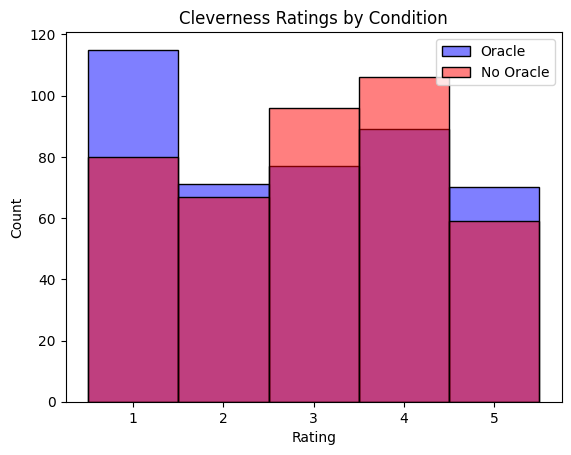

In [38]:
bins = np.arange(0.5, 6.5, 1)

sns.histplot(
    df_oracle["cleverness"], color="blue", alpha=0.5, label="Oracle", bins=bins
)
sns.histplot(
    df_no_oracle["cleverness"], color="red", alpha=0.5, label="No Oracle", bins=bins
)
plt.title("Cleverness Ratings by Condition")
plt.xlabel("Rating")


plt.xticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"])
plt.legend()
plt.savefig("cleverness.png", dpi=300)

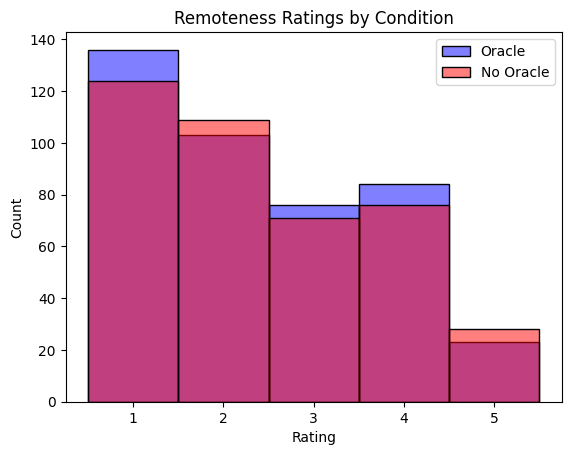

In [15]:
bins = np.arange(0.5, 6.5, 1)

sns.histplot(
    df_oracle["remoteness"], color="blue", alpha=0.5, label="Oracle", bins=bins
)
sns.histplot(
    df_no_oracle["remoteness"], color="red", alpha=0.5, label="No Oracle", bins=bins
)
plt.title("Remoteness Ratings by Condition")
plt.xlabel("Rating")


plt.xticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"])
plt.legend()
plt.savefig("remoteness.png", dpi=300)

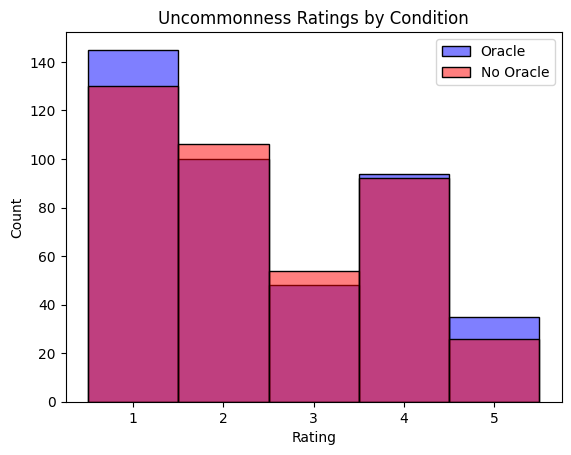

In [16]:
bins = np.arange(0.5, 6.5, 1)

sns.histplot(
    df_oracle["uncommonness"], color="blue", alpha=0.5, label="Oracle", bins=bins
)
sns.histplot(
    df_no_oracle["uncommonness"], color="red", alpha=0.5, label="No Oracle", bins=bins
)
plt.title("Uncommonness Ratings by Condition")
plt.xlabel("Rating")


plt.xticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"])
plt.legend()
plt.savefig("uncommonness.png", dpi=300)

### Check for participant accuracy in originality evals

In [39]:
SCORING_SCALE = (1, 5)  # Min and max scores
min_factor = df["originality_rescaled_factor"].min()
max_factor = df["originality_rescaled_factor"].max()
df_oracle["scaled_score"] = (
    (df_oracle["originality_rescaled_factor"] - min_factor)
    / (max_factor - min_factor)
    * (SCORING_SCALE[1] - SCORING_SCALE[0])
    + SCORING_SCALE[0]
).round()

df_no_oracle["scaled_score"] = (
    (df_no_oracle["originality_rescaled_factor"] - min_factor)
    / (max_factor - min_factor)
    * (SCORING_SCALE[1] - SCORING_SCALE[0])
    + SCORING_SCALE[0]
).round()

/tmp/ipykernel_2057407/2772158454.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oracle["scaled_score"] = (
/tmp/ipykernel_2057407/2772158454.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_oracle["scaled_score"] = (


In [40]:
from scipy.stats import pearsonr

print(pearsonr(df_oracle["scaled_score"], df_oracle["originality"]))
print(pearsonr(df_oracle["scaled_score"], df_oracle["cleverness"]))
print(pearsonr(df_oracle["scaled_score"], df_oracle["remoteness"]))
print(pearsonr(df_oracle["scaled_score"], df_oracle["uncommonness"]))

PearsonRResult(statistic=0.4360097875314238, pvalue=5.2043245063595445e-21)
PearsonRResult(statistic=0.3841632041816698, pvalue=2.734657930595073e-16)
PearsonRResult(statistic=0.24164113539892407, pvalue=5.064221805473548e-07)
PearsonRResult(statistic=0.423845649207918, pvalue=7.91842951145334e-20)


In [41]:
print(pearsonr(df_no_oracle["scaled_score"], df_no_oracle["originality"]))
print(pearsonr(df_no_oracle["scaled_score"], df_no_oracle["cleverness"]))
print(pearsonr(df_no_oracle["scaled_score"], df_no_oracle["remoteness"]))
print(pearsonr(df_no_oracle["scaled_score"], df_no_oracle["uncommonness"]))

PearsonRResult(statistic=0.4745522419306286, pvalue=2.6487909448388784e-24)
PearsonRResult(statistic=0.3243167695413168, pvalue=1.905552253183112e-11)
PearsonRResult(statistic=0.3027995122745726, pvalue=4.246593642983757e-10)
PearsonRResult(statistic=0.42291405476502814, pvalue=3.9218505064015835e-19)


# Does the oracle affect participant explanations?

### A first pass using topic models

### Topic modeling implementations

### Plotting and performance metrics

So the only interpretable topics are either specific to an item or are vague claims abt how the idea is already widely used, is original, etc. This isn't what we need

### A second attempt using a LLM-based LIWC

In [127]:
# TODO: Need to go back and rerun these with NA explanations removed after Jimmy finishes cleaning the data.
past_future_prompt = """
Are the words in this text past-focused or future-focused? ANSWER ONLY WITH A NUMBER: 1 if past-focused, 2 if future-focused. Here is the text:
"""
perceptual_details_prompt = """
Perceptual details refer to the process of perceiving and are indicated by words like "observing," "seen," "heard," "feeling," "listen," or "touch," among others. Does this text contain perceptual details? ANSWER ONLY WITH A NUMBER: 1 if the text doesn't contain perceptual details, 2 if the text does contain perceptual details. Here is the text:"""

causaual_analytical_prompt = """
Casual/analytical markers refer to performing structured evaluation of ideas. The cause/insight/analytical LIWC category words are example markers of causal processes. Causual markers are contrasted with intuitive markers, which do not indicate a structured evaluation and instead mark an intuitive (e.g., "gut feeling") one. Does this text conthttps://3.basecamp.com/5438755/circles/40468886ain causal/analytical markers? ANSWER ONLY WITH A NUMBER: 1 if the text uses an intuitive and not analytical approach, 2 if the text uses a structured and analytical approach. Here is the text:"""

comparative_prompt = """
Comparative language tracks explicit references to standards or examples and includes comparing or contrasting ideas or drawing distinctions among ideas. Does this text contain comparative language? ANSWER ONLY WITH A NUMBER: 1 if the text doesn't contain comparative language, 2 if the text does contain comparative language. Here is the text:"""

cleverness_prompt = """
Does this text refer to the cleverness, wittiness, shrewdness, or ingenuity of an idea? ANSWER ONLY WITH A NUMBER: 1 if the text doesn't refer to cleverness, 2 if the text does refer to cleverness. Here is the text:"""

In [ ]:
import anthropic
import os
from openai import OpenAI
from keys import ANTHROPIC_API_KEY, OPENAI_API_KEY

model = "openai"

if model == "anthropic":
    client = anthropic.Anthropic(
        # defaults to os.environ.get("ANTHROPIC_API_KEY")
        api_key=ANTHROPIC_API_KEY,
    )
elif model == "openai":
    client = OpenAI(api_key=OPENAI_API_KEY)

In [ ]:
if model == "anthropic":
    e_no_c_predictions = pd.read_csv(
        "../data/LIWC_no_oracle_Claude_Ratings.csv",
        index_col=0,
    )
    e_with_c_predictions = pd.read_csv(
        "../data/LIWC_oracle_Claude_Ratings.csv",
        index_col=0,
    )

elif model == "openai":
    e_no_c_predictions = pd.read_csv(
        "../data/LIWC_no_oracle_OpenAI_Ratings.csv",
        index_col=0,
    )
    e_with_c_predictions = pd.read_csv(
        "../data/LIWC_oracle_OpenAI_Ratings.csv",
        index_col=0,
    )

In [129]:
e_no_c_predictions = pd.DataFrame(
    columns=[
        "text",
        "past_future",
        "perceptual_details",
        "causal_analytical",
        "comparative",
        "cleverness",
    ]
)
e_with_c_predictions = pd.DataFrame(
    columns=[
        "text",
        "past_future",
        "perceptual_details",
        "causal_analytical",
        "comparative",
        "cleverness",
    ]
)

In [ ]:
from tqdm import tqdm

for explanation in tqdm(df_no_oracle["explanation"]):
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = past_future_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text
    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content

    e_no_c_row = pd.DataFrame(
        {
            "text": explanation,
            "past_future": pred,
            "perceptual_details": None,
            "causal_analytical": None,
            "comparative": None,
            "cleverness": None,
        },
        index=[0],
    )
    e_no_c_predictions = pd.concat([e_no_c_predictions, e_no_c_row], ignore_index=True)

100%|██████████| 408/408 [03:54<00:00,  1.74it/s]


In [134]:
e_no_c_predictions = e_no_c_predictions.loc[
    (e_no_c_predictions["past_future"] == "1")
    | (e_no_c_predictions["past_future"] == "2")
]

In [ ]:
for explanation in tqdm(df_oracle["explanation"]):
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = past_future_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text

    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content

    e_with_c_row = pd.DataFrame(
        {
            "text": explanation,
            "past_future": pred,
            "perceptual_details": None,
            "causal_analytical": None,
            "comparative": None,
            "cleverness": None,
        },
        index=[0],
    )
    e_with_c_predictions = pd.concat(
        [e_with_c_predictions, e_with_c_row], ignore_index=True
    )

100%|██████████| 422/422 [04:29<00:00,  1.57it/s]


In [137]:
e_with_c_predictions = e_with_c_predictions.loc[
    (e_with_c_predictions["past_future"] == "1")
    | (e_with_c_predictions["past_future"] == "2")
]

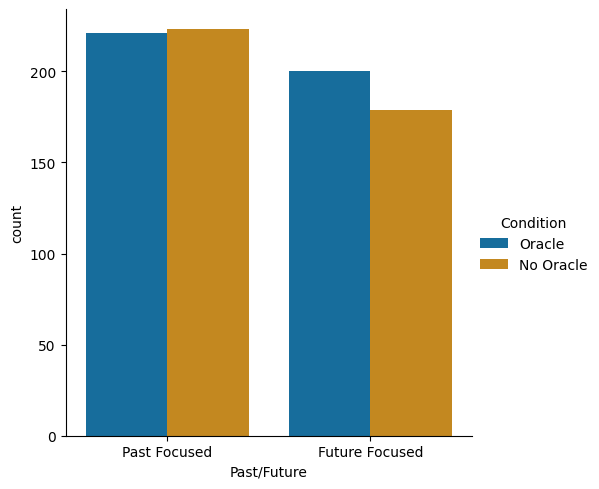

In [ ]:
# Combine data with condition labels
oracle_df = e_with_c_predictions.copy()
oracle_df["Condition"] = "Oracle"
no_oracle_df = e_no_c_predictions.copy()
no_oracle_df["Condition"] = "No Oracle"
combined_df = pd.concat([oracle_df, no_oracle_df])

# sns.histplot(
#     e_with_c_predictions["past_future"],
#     color="blue",
#     label="Oracle",
#     binwidth=0.5,
#     shrink=0.8,
#     multiple="dodge",
#     stat="count",
# )
# sns.histplot(
#     e_no_c_predictions["past_future"],
#     color="red",
#     label="No Oracle",
#     binwidth=0.5,
#     shrink=0.8,
#     multiple="dodge",
#     stat="count",
# )

# Create catplot
past_future_human = sns.catplot(
    data=combined_df,
    x="past_future",
    hue="Condition",
    kind="count",
    # palette={"Oracle": "blue", "No Oracle": "red"}
)


# elif model == "anthropic":
#     past_future_human.set_title("Human Past/Future Language Use by Condition - Claude")
# elif model == "openai":
#     plt.title("Human Past/Future Language Use by Condition - OpenAI")

past_future_human.set_xlabels("Past/Future")
past_future_human.set_xticklabels(["Past Focused", "Future Focused"])
# plt.savefig("past_future_human.svg", dpi=300)

In [140]:
mannwhitneyu(
    e_with_c_predictions["past_future"].astype(int),
    e_no_c_predictions["past_future"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=87141.5, pvalue=0.3918587522530199)

In [ ]:
from tqdm import tqdm

for index, row in tqdm(e_no_c_predictions.iterrows(), total=len(e_no_c_predictions)):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = perceptual_details_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text

    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_no_c_predictions.at[index, "perceptual_details"] = pred

100%|██████████| 402/402 [04:07<00:00,  1.62it/s]


In [142]:
e_no_c_predictions["perceptual_details"].value_counts()

perceptual_details
1    372
2     30
Name: count, dtype: int64

In [143]:
e_no_c_predictions = e_no_c_predictions[
    (e_no_c_predictions["perceptual_details"] == "1")
    | (e_no_c_predictions["perceptual_details"] == "2")
]

In [ ]:
for index, row in tqdm(
    e_with_c_predictions.iterrows(), total=len(e_with_c_predictions)
):
    # skip prolific IDs
    explanation = row["text"]
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = perceptual_details_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text
    
    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_with_c_predictions.at[index, "perceptual_details"] = pred

100%|██████████| 421/421 [04:08<00:00,  1.69it/s]


In [145]:
e_with_c_predictions = e_with_c_predictions[
    (e_with_c_predictions["perceptual_details"] == "1")
    | (e_with_c_predictions["perceptual_details"] == "2")
]

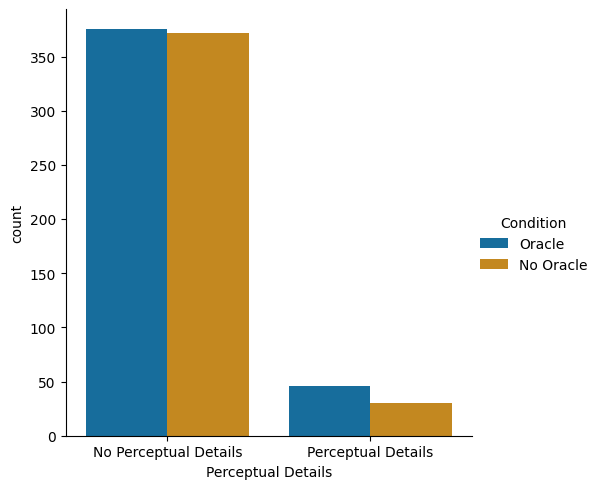

In [ ]:
# sns.histplot(e_with_c_predictions["perceptual_details"], color="blue")
# sns.histplot(e_no_c_predictions["perceptual_details"], color="red")
# elif model == "anthropic":
#     plt.title("Perceptual Details by condition - Claude")
# elif model == "openai":
#     plt.title("Perceptual Details by condition - OpenAI")


# Create catplot
perceptual_details_human = sns.catplot(
    data=combined_df,
    x="perceptual_details",
    hue="Condition",
    kind="count",
    # palette={"Oracle": "blue", "No Oracle": "red"}
)

# elif model == "anthropic":
#     perceptual_details_human.set_title("Human Perceptual Details Use by Condition - Claude")
# elif model == "openai":
#     perceptual_details_human.set_("Human Perceptual Details Use by Condition - OpenAI")

perceptual_details_human.set_xlabels("Perceptual Details")
perceptual_details_human.set_xticklabels(
    ["No Perceptual Details", "Perceptual Details"]
)
# plt.savefig("past_future_human.svg", dpi=300)

In [148]:
mannwhitneyu(
    e_with_c_predictions["perceptual_details"].astype(int),
    e_no_c_predictions["perceptual_details"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=87552.0, pvalue=0.08647390870404337)

In [ ]:
from tqdm import tqdm

for index, row in tqdm(e_no_c_predictions.iterrows(), total=len(e_no_c_predictions)):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = causaual_analytical_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text
    
    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_no_c_predictions.at[index, "causal_analytical"] = pred

100%|██████████| 402/402 [04:04<00:00,  1.64it/s]


In [150]:
e_no_c_predictions = e_no_c_predictions[
    (e_no_c_predictions["causal_analytical"] == "1")
    | (e_no_c_predictions["causal_analytical"] == "2")
]
len(e_no_c_predictions)

402

In [ ]:
from tqdm import tqdm

for index, row in tqdm(
    e_with_c_predictions.iterrows(), total=len(e_with_c_predictions)
):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = causaual_analytical_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text
    
    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_with_c_predictions.at[index, "causal_analytical"] = pred

100%|██████████| 421/421 [03:53<00:00,  1.80it/s]


In [152]:
e_with_c_predictions = e_with_c_predictions[
    (e_with_c_predictions["causal_analytical"] == "1")
    | (e_with_c_predictions["causal_analytical"] == "2")
]
len(e_with_c_predictions)

421

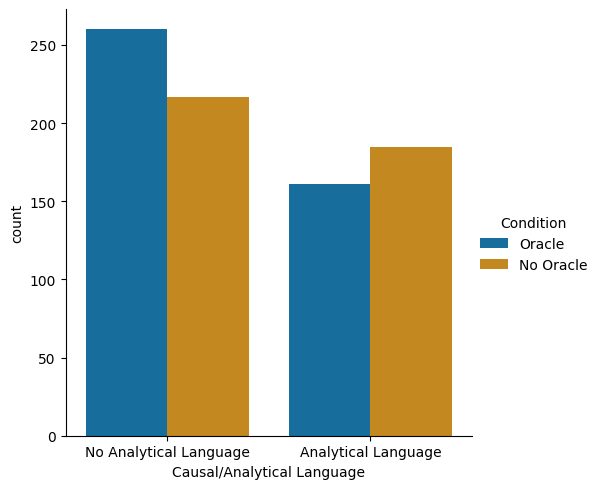

In [ ]:
# sns.histplot(e_with_c_predictions["causal_analytical"], color="blue")
# sns.histplot(e_no_c_predictions["causal_analytical"], color="red")
# if model == "anthropic":
#     plt.title("Causal/analytical by condition - Claude")
# elif model == "openai":
#     plt.title("Causal/analytical by condition - OpenAI")

# Create catplot
causal_analytical_human = sns.catplot(
    data=combined_df,
    x="causal_analytical",
    hue="Condition",
    kind="count",
    # palette={"Oracle": "blue", "No Oracle": "red"}
)


# if model == "anthropic":
#     perceptual_details_human.set_title("Human Perceptual Details Use by Condition - Claude")
# elif model == "openai":
#     perceptual_details_human.set_("Human Perceptual Details Use by Condition - OpenAI")

causal_analytical_human.set_xlabels("Causal/Analytical Language")
causal_analytical_human.set_xticklabels(
    ["No Analytical Language", "Analytical Language"]
)
# plt.savefig("past_future_human.svg", dpi=300)

In [155]:
mannwhitneyu(
    e_with_c_predictions["causal_analytical"].astype(int),
    e_no_c_predictions["causal_analytical"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=78039.5, pvalue=0.023951318105222573)

In [ ]:
from tqdm import tqdm

for index, row in tqdm(e_no_c_predictions.iterrows(), total=len(e_no_c_predictions)):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = comparative_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text

    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_no_c_predictions.at[index, "comparative"] = pred

100%|██████████| 402/402 [04:05<00:00,  1.64it/s]


In [157]:
e_no_c_predictions = e_no_c_predictions[
    (e_no_c_predictions["comparative"] == "1")
    | (e_no_c_predictions["comparative"] == "2")
]
len(e_no_c_predictions)

402

In [ ]:
from tqdm import tqdm

for index, row in tqdm(
    e_with_c_predictions.iterrows(), total=len(e_with_c_predictions)
):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = comparative_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text

    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_with_c_predictions.at[index, "comparative"] = pred

100%|██████████| 421/421 [04:06<00:00,  1.71it/s]


In [159]:
e_with_c_predictions = e_with_c_predictions[
    (e_with_c_predictions["comparative"] == "1")
    | (e_with_c_predictions["comparative"] == "2")
]
len(e_with_c_predictions)

421

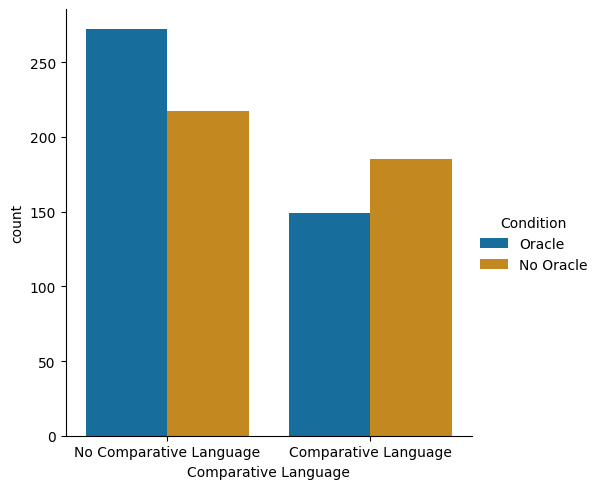

In [ ]:
# sns.histplot(e_with_c_predictions["comparative"], color="blue")
# sns.histplot(e_no_c_predictions["comparative"], color="red")
# if model == "anthropic":
#     plt.title("Comparative by condition - Claude")
# elif model == "openai":
#     plt.title("Comparative by condition - OpenAI")

# Create catplot
comparative_human = sns.catplot(
    data=combined_df,
    x="comparative",
    hue="Condition",
    kind="count",
    # palette={"Oracle": "blue", "No Oracle": "red"}
)


# if model == "anthropic":
#     perceptual_details_human.set_title("Human Perceptual Details Use by Condition - Claude")
# elif model == "openai":
#     perceptual_details_human.set_("Human Perceptual Details Use by Condition - OpenAI")

comparative_human.set_xlabels("Comparative Language")
comparative_human.set_xticklabels(["No Comparative Language", "Comparative Language"])

In [161]:
mannwhitneyu(
    e_with_c_predictions["comparative"].astype(int),
    e_no_c_predictions["comparative"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=75627.5, pvalue=0.0019246404861256458)

In [ ]:
for index, row in tqdm(e_no_c_predictions.iterrows(), total=len(e_no_c_predictions)):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = cleverness_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text
    
    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_no_c_predictions.at[index, "cleverness"] = pred

100%|██████████| 402/402 [03:56<00:00,  1.70it/s]


In [163]:
e_no_c_predictions = e_no_c_predictions[
    (e_no_c_predictions["cleverness"] == "1")
    | (e_no_c_predictions["cleverness"] == "2")
]
len(e_no_c_predictions)

402

In [ ]:
from tqdm import tqdm

for index, row in tqdm(
    e_with_c_predictions.iterrows(), total=len(e_with_c_predictions)
):
    explanation = row["text"]
    # skip prolific IDs
    tokens = word_tokenize(explanation.lower())
    if len(tokens) == 1:
        continue
    prompt = cleverness_prompt + "\n" + explanation
    if model == "anthropic":
        message = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
        )
        pred = message.content[0].text

    elif model == "openai":
        message = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": [{"type": "text", "text": prompt}]}],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred = message.choices[0].message.content
    e_with_c_predictions.at[index, "cleverness"] = pred

100%|██████████| 421/421 [04:11<00:00,  1.67it/s]


In [165]:
e_with_c_predictions = e_with_c_predictions[
    (e_with_c_predictions["cleverness"] == "1")
    | (e_with_c_predictions["cleverness"] == "2")
]
len(e_with_c_predictions)

421

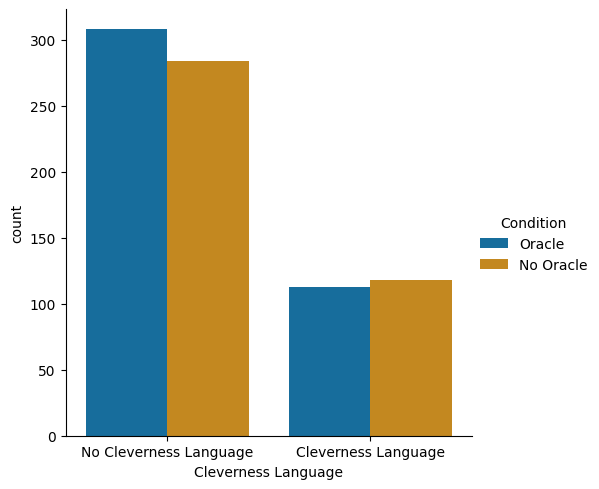

In [ ]:
# sns.histplot(e_with_c_predictions["cleverness"], color="blue")
# sns.histplot(e_no_c_predictions["cleverness"], color="red")
# if model == "anthropic":
#     plt.title("Cleverness by condition - Claude")
# elif model == "openai":
#     plt.title("Cleverness by condition - OpenAI")

# Create catplot
cleverness_human = sns.catplot(
    data=combined_df,
    x="cleverness",
    hue="Condition",
    kind="count",
    # palette={"Oracle": "blue", "No Oracle": "red"}
)


# if model == "anthropic":
#     perceptual_details_human.set_title("Human Perceptual Details Use by Condition - Claude")
# elif model == "openai":
#     perceptual_details_human.set_("Human Perceptual Details Use by Condition - OpenAI")

cleverness_human.set_xlabels("Cleverness Language")
cleverness_human.set_xticklabels(["No Cleverness Language", "Cleverness Language"])

In [167]:
mannwhitneyu(
    e_with_c_predictions["cleverness"].astype(int),
    e_no_c_predictions["cleverness"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=82495.0, pvalue=0.4230530791208832)

In [ ]:
if model == "anthropic":
    e_no_c_predictions.to_csv(
        "../data/LIWC_no_oracle_Claude_Ratings.csv"
    )
    e_with_c_predictions.to_csv(
        "../data/LIWC_oracle_Claude_Ratings.csv"
    )
elif model == "openai":
    e_no_c_predictions.to_csv(
        "../data/LIWC_no_oracle_OpenAI_Ratings.csv"
    )
    e_with_c_predictions.to_csv(
        "../data/LIWC_oracle_OpenAI_Ratings.csv"
    )

### Check for intercollerations among LLMs

In [5]:
e_no_c_predictions_claude = pd.read_csv(
    "../data/LIWC_no_oracle_Claude_Ratings.csv",
    index_col=0,
)
e_with_c_predictions_claude = pd.read_csv(
    "../data/LIWC_oracle_Claude_Ratings.csv",
    index_col=0,
)

e_no_c_predictions_openai = pd.read_csv(
    "../data/LIWC_no_oracle_OpenAI_Ratings.csv",
    index_col=0,
)
e_with_c_predictions_openai = pd.read_csv(
    "../data/LIWC_oracle_OpenAI_Ratings.csv",
    index_col=0,
)

In [6]:
e_no_c_predictions_claude

,text,past_future,perceptual_details,causal_analytical,comparative,cleverness
0,So far the most original response. I have yet ...,2,2,2,2,2
1,This idea though practical lacks revolutionary...,1,1,2,2,1
2,the problem appera to be uncommon.,2,1,1,1,1
3,The usage of things such as color coding and m...,1,1,2,2,1
4,This response suggests a novel approach by int...,2,1,2,1,2
...,...,...,...,...,...,...
398,This is a generic response that could be appli...,2,1,1,1,1
399,Other alternatives to flights are considered b...,2,1,2,2,1
400,Alternatives to flight is the most common way ...,2,1,1,2,2
401,I rated very unoriginal because this is a solu...,1,1,2,2,1


In [7]:
from scipy.stats.contingency import association

print("No oracle associations:")
print("Past/Future:")
print(
    association(
        pd.crosstab(
            e_no_c_predictions_openai["past_future"],
            e_no_c_predictions_claude["past_future"],
        )
    )
)
print("Perceptual Details:")
print(
    association(
        pd.crosstab(
            e_no_c_predictions_openai["perceptual_details"],
            e_no_c_predictions_claude["perceptual_details"],
        )
    )
)
print("Causal/Analytical:")
print(
    association(
        pd.crosstab(
            e_no_c_predictions_openai["causal_analytical"],
            e_no_c_predictions_claude["causal_analytical"],
        )
    )
)
print("Comparative:")
print(
    association(
        pd.crosstab(
            e_no_c_predictions_openai["comparative"],
            e_no_c_predictions_claude["comparative"],
        )
    )
)

No oracle associations:
Past/Future:
0.738023487513481
Perceptual Details:
0.7072920502000067
Causal/Analytical:
0.5698783088909997
Comparative:
0.5487394453423522


In [8]:
print("Oracle associations:")
print("Past/Future:")
print(
    association(
        pd.crosstab(
            e_with_c_predictions_openai["past_future"],
            e_with_c_predictions_claude["past_future"],
        )
    )
)
print("Perceptual Details:")
print(
    association(
        pd.crosstab(
            e_with_c_predictions_openai["perceptual_details"],
            e_with_c_predictions_claude["perceptual_details"],
        )
    )
)
print("Causal/Analytical:")
print(
    association(
        pd.crosstab(
            e_with_c_predictions_openai["causal_analytical"],
            e_with_c_predictions_claude["causal_analytical"],
        )
    )
)
print("Comparative:")
print(
    association(
        pd.crosstab(
            e_with_c_predictions_openai["comparative"],
            e_with_c_predictions_claude["comparative"],
        )
    )
)

Oracle associations:
Past/Future:
0.6935610581129743
Perceptual Details:
0.7978360503056658
Causal/Analytical:
0.5927906769790553
Comparative:
0.5661338512046022


# Make graphs for submission

In [45]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("Correlations_Claude.csv")
df["Condition"] = df["Condition"].replace(
    {"oracle": "Oracle", "no oracle": "No Oracle"}
)
df = pd.melt(df, id_vars=["Condition"], var_name="correlation", value_name="value")
df = df.pivot(index="Condition", columns="correlation", values="value")

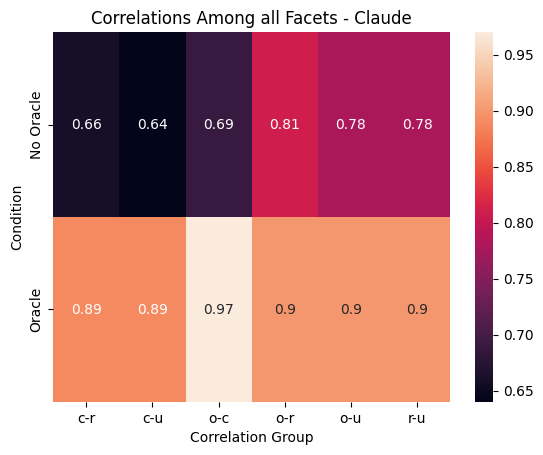

In [46]:
import matplotlib.pyplot as plt

sns.set_palette("colorblind")
sns.heatmap(df, annot=True)
plt.title("Correlations Among all Facets - Claude")
plt.xlabel("Correlation Group")
plt.savefig("Correlations_claude.svg", dpi=300)

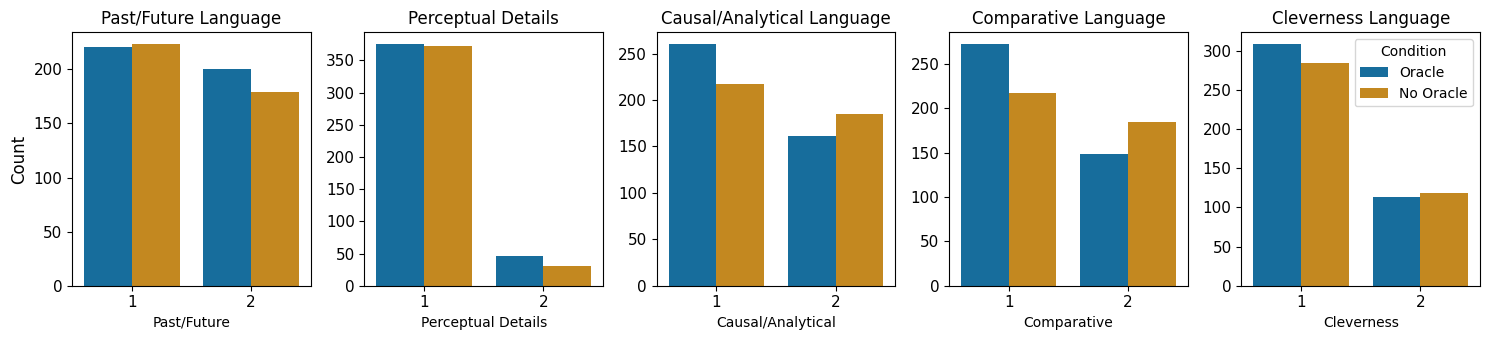

In [111]:
# catplot grid - human ratings
fig = plt.figure(figsize=(15, 3.5))

conditions = [
    "past_future",
    "perceptual_details",
    "causal_analytical",
    "comparative",
    "cleverness",
]
titles = [
    "Past/Future Language",
    "Perceptual Details",
    "Causal/Analytical Language",
    "Comparative Language",
    "Cleverness Language",
]
x_labels = [
    "Past/Future",
    "Perceptual Details",
    "Causal/Analytical",
    "Comparative",
    "Cleverness",
]

for i, title in enumerate(titles, 1):
    # Create subplot
    ax = plt.subplot(1, 5, i)

    # Create catplot directly in the subplot
    sns.countplot(
        data=combined_df,
        x=conditions[i - 1],
        hue="Condition",
        # kind="count",
        ax=plt.gca(),
        legend=False if i < 5 else True,  # Only show legend on last plot
    )

    # Set title based on model
    plt.title(title)
    plt.xlabel(x_labels[i - 1])
    # Set y-label only for first plot
    if i == 1:
        plt.ylabel("Count", fontsize=12)
    else:
        plt.ylabel("")
    ax.tick_params(axis="both", which="major", labelsize=11)


plt.tight_layout()
plt.show()
fig.savefig("facet_counts_human.svg", dpi=300)

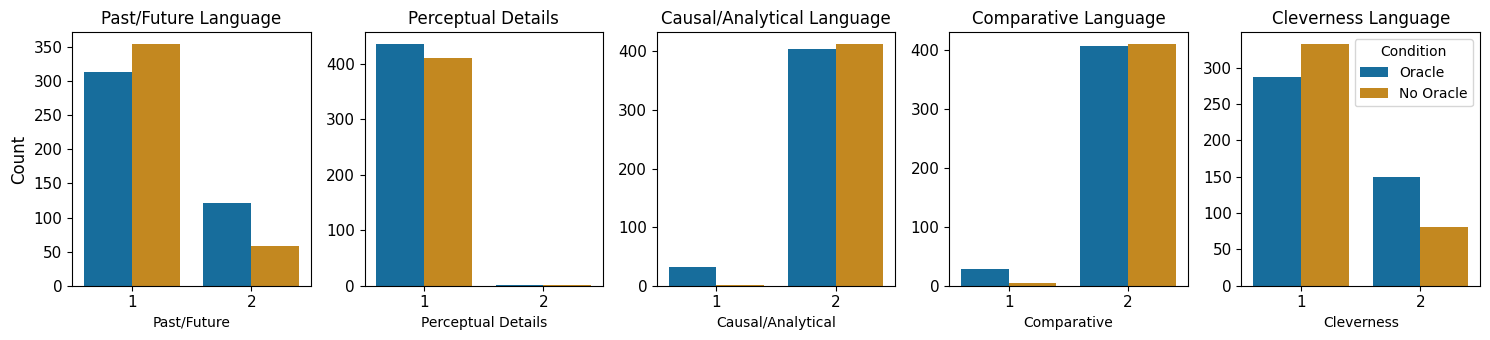

In [106]:
# catplot grid - AI
fig = plt.figure(figsize=(15, 3.5))

conditions = [
    "past_future_gpt",
    "perceptual_details_gpt",
    "causual_analytical_gpt",
    "comparative_gpt",
    "cleverness_gpt",
]
titles = [
    "Past/Future Language",
    "Perceptual Details",
    "Causal/Analytical Language",
    "Comparative Language",
    "Cleverness Language",
]
x_labels = [
    "Past/Future",
    "Perceptual Details",
    "Causal/Analytical",
    "Comparative",
    "Cleverness",
]

for i, title in enumerate(titles, 1):
    # Create subplot
    ax = plt.subplot(1, 5, i)

    # Create catplot directly in the subplot
    sns.countplot(
        data=combined_df,
        x=conditions[i - 1],
        hue="Condition",
        # kind="count",
        ax=plt.gca(),
        legend=False if i < 5 else True,  # Only show legend on last plot
    )

    # Set title based on model
    plt.title(title)
    plt.xlabel(x_labels[i - 1])
    # Set y-label only for first plot
    if i == 1:
        plt.ylabel("Count", fontsize=12)
    else:
        plt.ylabel("")
    ax.tick_params(axis="both", which="major", labelsize=11)


plt.tight_layout()
plt.show()
fig.savefig("facet_counts_ai.svg", dpi=300)

In [101]:
combined_df.columns

Index(['text_gpt', 'past_future_claude', 'past_future_gpt',
       'perceptual_details_claude', 'perceptual_details_gpt',
       'causal_analytical_claude', 'causal_analytical_gpt',
       'comparative_claude', 'comparative_gpt', 'cleverness_claude',
       'cleverness_gpt', 'causual_analytical_claude', 'causual_analytical_gpt',
       'Condition'],
      dtype='object')

# AI Correlational Analysis

In [17]:
import pandas as pd
import os
import time
import numpy as np
import pandas as pd
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
from scipy.stats import linregress

CONDITION = "no_oracle"
correlation_plot = os.path.join(os.getcwd(), f"correlation_plot_{CONDITION}_LLM.png")
agreement_plot = os.path.join(os.getcwd(), f"model_agreement_plot_{CONDITION}_LLM.png")
df = pd.read_csv(f"./AI_Responses/dpt_scores_{CONDITION}_LLM.csv")
df.dropna(inplace=True)
df.reset_index(inplace=True)

In [15]:
df_oracle = pd.read_csv(f"./AI_Responses/dpt_scores_oracle_LLM.csv")
df_no_oracle = pd.read_csv(f"./AI_Responses/dpt_scores_no_oracle_LLM.csv")

In [11]:
df_oracle.columns

Index(['Response', 'Claude_Originality', 'Claude_Uncommon', 'Claude_Remote',
       'Claude_Clever', 'Claude_Explanation', 'GPT4o_Originality',
       'GPT4o_Uncommon', 'GPT4o_Remote', 'GPT4o_Clever', 'GPT4o_Explanation',
       'Average_Originality', 'Average_Uncommon', 'Average_Remote',
       'Average_Clever', 'Original_Score'],
      dtype='object')

In [14]:
df_oracle_claude = df_oracle[
    ["Claude_Originality", "Claude_Uncommon", "Claude_Remote", "Claude_Clever"]
]
df_oracle_openai = df_oracle[
    ["GPT4o_Originality", "GPT4o_Uncommon", "GPT4o_Remote", "GPT4o_Clever"]
]
df_no_oracle_claude = df_no_oracle[
    ["Claude_Originality", "Claude_Uncommon", "Claude_Remote", "Claude_Clever"]
]
df_no_oracle_openai = df_no_oracle[
    ["GPT4o_Originality", "GPT4o_Uncommon", "GPT4o_Remote", "GPT4o_Clever"]
]

df_oracle_claude.to_csv("Claude_Oracle_LLM.csv")
df_oracle_openai.to_csv("OpenAI_Oracle_LLM.csv")
df_no_oracle_claude.to_csv("Claude_No_Oracle_LLM.csv")
df_no_oracle_openai.to_csv("OpenAI_No_Oracle_LLM.csv")

In [8]:
len(df_oracle)

436

In [9]:
len(df_oracle.drop_duplicates(subset=["Response"]))

225

In [10]:
len(df_oracle.drop_duplicates(subset=["Claude_Explanation"]))
# df.drop_duplicates(subset=["Response"])

228

In [11]:
len(df_oracle.drop_duplicates(subset=["GPT4o_Explanation"]))

370

In [43]:
df_claude = df.drop_duplicates(subset=["Claude_Explanation"])
len(df_claude)

236

In [44]:
df_gpt4o = df.drop_duplicates(subset=["GPT4o_Explanation"])
len(df_gpt4o)

376

In [20]:
df_no_oracle.columns

Index(['index', 'Response', 'Claude_Originality', 'Claude_Uncommon',
       'Claude_Remote', 'Claude_Clever', 'Claude_Explanation',
       'GPT4o_Originality', 'GPT4o_Uncommon', 'GPT4o_Remote', 'GPT4o_Clever',
       'GPT4o_Explanation', 'Average_Originality', 'Average_Uncommon',
       'Average_Remote', 'Average_Clever', 'Original_Score'],
      dtype='object')

In [22]:
print(pearsonr(df_no_oracle["Claude_Clever"], df_no_oracle["Claude_Remote"]))
print(pearsonr(df_no_oracle["Claude_Clever"], df_no_oracle["Claude_Uncommon"]))
print(pearsonr(df_no_oracle["Claude_Remote"], df_no_oracle["Claude_Uncommon"]))

PearsonRResult(statistic=0.6587521000331644, pvalue=9.674970628453855e-53)
PearsonRResult(statistic=0.6378771213596013, pvalue=1.4730228921386814e-48)
PearsonRResult(statistic=0.7763563021167887, pvalue=2.0717138069655033e-84)


In [23]:
print(pearsonr(df_oracle["Claude_Clever"], df_oracle["Claude_Remote"]))
print(pearsonr(df_oracle["Claude_Clever"], df_oracle["Claude_Uncommon"]))
print(pearsonr(df_oracle["Claude_Remote"], df_oracle["Claude_Uncommon"]))

PearsonRResult(statistic=0.8857047794748543, pvalue=1.0122021786610563e-146)
PearsonRResult(statistic=0.8864441724673855, pvalue=2.6928166202083526e-147)
PearsonRResult(statistic=0.8983534872485893, pvalue=3.7683930685185693e-157)


In [24]:
print(pearsonr(df_no_oracle["GPT4o_Clever"], df_no_oracle["GPT4o_Remote"]))
print(pearsonr(df_no_oracle["GPT4o_Clever"], df_no_oracle["GPT4o_Uncommon"]))
print(pearsonr(df_no_oracle["GPT4o_Remote"], df_no_oracle["GPT4o_Uncommon"]))

PearsonRResult(statistic=0.8156948030930943, pvalue=9.63781843506517e-100)
PearsonRResult(statistic=0.8185624133947321, pvalue=5.294027695815651e-101)
PearsonRResult(statistic=0.9054270952251946, pvalue=4.967736162284969e-155)


In [25]:
print(pearsonr(df_oracle["GPT4o_Clever"], df_oracle["GPT4o_Remote"]))
print(pearsonr(df_oracle["GPT4o_Clever"], df_oracle["GPT4o_Uncommon"]))
print(pearsonr(df_oracle["GPT4o_Remote"], df_oracle["GPT4o_Uncommon"]))

PearsonRResult(statistic=0.9429163028588562, pvalue=2.3227903847634704e-209)
PearsonRResult(statistic=0.9665285753170269, pvalue=1.530798057531687e-258)
PearsonRResult(statistic=0.9714808128246453, pvalue=2.138927183885636e-273)


In [27]:
print(pearsonr(df_no_oracle["Claude_Originality"], df_no_oracle["Claude_Clever"]))
print(pearsonr(df_no_oracle["Claude_Originality"], df_no_oracle["Claude_Remote"]))
print(pearsonr(df_no_oracle["Claude_Originality"], df_no_oracle["Claude_Uncommon"]))

PearsonRResult(statistic=0.6934900931291197, pvalue=1.705186220636831e-60)
PearsonRResult(statistic=0.806910446783516, pvalue=5.14368060931546e-96)
PearsonRResult(statistic=0.7750642554465841, pvalue=5.837552991910003e-84)


In [28]:
print(pearsonr(df_oracle["Claude_Originality"], df_oracle["Claude_Clever"]))
print(pearsonr(df_oracle["Claude_Originality"], df_oracle["Claude_Remote"]))
print(pearsonr(df_oracle["Claude_Originality"], df_oracle["Claude_Uncommon"]))

PearsonRResult(statistic=0.9695551786527334, pvalue=2.492369053688787e-267)
PearsonRResult(statistic=0.9014102305924256, pvalue=7.059256835239438e-160)
PearsonRResult(statistic=0.8957062969043557, pvalue=7.3936313791363425e-155)


In [29]:
print(pearsonr(df_no_oracle["GPT4o_Originality"], df_no_oracle["GPT4o_Clever"]))
print(pearsonr(df_no_oracle["GPT4o_Originality"], df_no_oracle["GPT4o_Remote"]))
print(pearsonr(df_no_oracle["GPT4o_Originality"], df_no_oracle["GPT4o_Uncommon"]))

PearsonRResult(statistic=0.8261142131399237, pvalue=1.9746377328430567e-104)
PearsonRResult(statistic=0.918863123635792, pvalue=4.37732883201932e-168)
PearsonRResult(statistic=0.9820920053288812, pvalue=4.598927792033532e-300)


In [30]:
print(pearsonr(df_oracle["GPT4o_Originality"], df_oracle["GPT4o_Clever"]))
print(pearsonr(df_oracle["GPT4o_Originality"], df_oracle["GPT4o_Remote"]))
print(pearsonr(df_oracle["GPT4o_Originality"], df_oracle["GPT4o_Uncommon"]))

PearsonRResult(statistic=0.9665285753170269, pvalue=1.530798057531687e-258)
PearsonRResult(statistic=0.9714808128246453, pvalue=2.138927183885636e-273)
PearsonRResult(statistic=0.9999999999999987, pvalue=0.0)


In [ ]:
import matplotlib.pyplot as plt

sns.set_palette("colorblind")
sns.heatmap(df, annot=True)
plt.title("Correlations Among all Likert Scales - Claude")
plt.xlabel("Correlation Group")
plt.savefig("Correlations.png", dpi=300)

In [2]:
def compute_correlations_and_plot(df: pd.DataFrame):
    """Compute correlations between all raters and create visualizations for multiple criteria"""
    criteria = ["Originality", "Uncommon", "Remote", "Clever"]
    models = ["Claude", "GPT4o"]

    for criterion in criteria:
        rating_cols = [f"{model}_{criterion}" for model in models] + ["Original_Score"]
        corr_matrix = df[rating_cols].corr()

        # Create correlation heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1)
        plt.title(f"{criterion} Rating Correlations Between Models and Original Scores")
        plt.tight_layout()
        plt.savefig(
            correlation_plot.replace(".png", f"_{criterion.lower()}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.close()

        # Create pairwise agreement plots
        # Calculate number of combinations for subplot layout
        num_combinations = len(list(combinations(rating_cols, 2)))
        num_rows = (num_combinations + 2) // 3  # Ceiling division to get number of rows
        plt.figure(figsize=(15, 5 * num_rows))

        for i, (col1, col2) in enumerate(combinations(rating_cols, 2)):
            plt.subplot(num_rows, 3, i + 1)
            sns.regplot(data=df, x=col1, y=col2, scatter_kws={"alpha": 0.5})
            # Calculate r squared
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                df[col1], df[col2]
            )
            r_squared = r_value**2
            plt.title(f'{col1.split("_")[0]} vs {col2.split("_")[0]}')
            plt.annotate(
                f"$R^2 = {r_squared:.2f}$",
                xy=(0.05, 0.95),
                xycoords="axes fraction",
                ha="left",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"
                ),
            )
        plt.tight_layout()
        plt.savefig(
            agreement_plot.replace(".png", f"_{criterion.lower()}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.close()

        # Print correlation statistics
        print(f"\nCorrelation Statistics for {criterion}:")
        for col1, col2 in combinations(rating_cols, 2):
            r, p = stats.pearsonr(df[col1], df[col2])
            print(
                f"{col1.split('_')[0]} vs {col2.split('_')[0]}: r = {r:.3f}, p = {p:.4f}"
            )

        # Print model agreement statistics
        model_cols = [f"{model}_{criterion}" for model in models]
        print(f"\nModel Agreement Statistics for {criterion}:")
        for col1, col2 in combinations(model_cols, 2):
            agreement = (df[col1] == df[col2]).mean() * 100
            print(
                f"{col1.split('_')[0]} vs {col2.split('_')[0]}: {agreement:.1f}% exact agreement"
            )

In [18]:
compute_correlations_and_plot(df_no_oracle)


Correlation Statistics for Originality:
Claude vs GPT4o: r = 0.775, p = 0.0000
Claude vs Original: r = 0.598, p = 0.0000
GPT4o vs Original: r = 0.666, p = 0.0000

Model Agreement Statistics for Originality:
Claude vs GPT4o: 66.1% exact agreement

Correlation Statistics for Uncommon:
Claude vs GPT4o: r = 0.779, p = 0.0000
Claude vs Original: r = 0.556, p = 0.0000
GPT4o vs Original: r = 0.683, p = 0.0000

Model Agreement Statistics for Uncommon:
Claude vs GPT4o: 66.8% exact agreement

Correlation Statistics for Remote:
Claude vs GPT4o: r = 0.736, p = 0.0000
Claude vs Original: r = 0.552, p = 0.0000
GPT4o vs Original: r = 0.641, p = 0.0000

Model Agreement Statistics for Remote:
Claude vs GPT4o: 58.8% exact agreement

Correlation Statistics for Clever:
Claude vs GPT4o: r = 0.728, p = 0.0000
Claude vs Original: r = 0.599, p = 0.0000
GPT4o vs Original: r = 0.731, p = 0.0000

Model Agreement Statistics for Clever:
Claude vs GPT4o: 57.6% exact agreement


## LLM LIWC

In [18]:
df_no_oracle = pd.read_csv(f"./AI_Responses/dpt_scores_no_oracle_LLM.csv")
df_no_oracle.dropna(inplace=True)
df_no_oracle.reset_index(inplace=True)
df_no_oracle.drop_duplicates(
    subset=["Claude_Explanation", "GPT4o_Explanation"], inplace=True
)

df_oracle = pd.read_csv(f"./AI_Responses/dpt_scores_oracle_LLM.csv")
df_oracle.dropna(inplace=True)
df_oracle.reset_index(inplace=True)
df_oracle.drop_duplicates(
    subset=["Claude_Explanation", "GPT4o_Explanation"], inplace=True
)

In [99]:
if model == "anthropic":
    e_no_c_predictions = pd.read_csv(
        "../data/LIWC_no_oracle_predictions_LLM_Anthropic.csv",
        index_col=0,
    )
    e_with_c_predictions = pd.read_csv(
        "../data/LIWC_oracle_predictions_LLM_Anthropic.csv",
        index_col=0,
    )
elif model == "openai":
    e_no_c_predictions = pd.read_csv(
        "../data/LIWC_no_oracle_predictions_LLM_OpenAI.csv",
        index_col=0,
    )
    e_with_c_predictions = pd.read_csv(
        "../data/LIWC_oracle_predictions_LLM_OpenAI.csv",
        index_col=0,
    )

In [128]:
past_future_prompt = """
Are the words in this text past-focused or future-focused? ANSWER ONLY WITH A NUMBER: 1 if past-focused, 2 if future-focused. Here is the text:
"""
perceptual_details_prompt = """
Perceptual details refer to the process of perceiving and are indicated by words like "observing," "seen," "heard," "feeling," "listen," or "touch," among others. Does this text contain perceptual details? ANSWER ONLY WITH A NUMBER: 1 if the text doesn't contain perceptual details, 2 if the text does contain perceptual details. Here is the text:"""

causaual_analytical_prompt = """
Casual/analytical markers refer to performing structured evaluation of ideas. The cause/insight/analytical LIWC category words are example markers of causal processes. Causual markers are contrasted with intuitive markers, which do not indicate a structured evaluation and instead mark an intuitive (e.g., "gut feeling") one. Does this text conthttps://3.basecamp.com/5438755/circles/40468886ain causal/analytical markers? ANSWER ONLY WITH A NUMBER: 1 if the text uses an intuitive and not analytical approach, 2 if the text uses a structured and analytical approach. Here is the text:"""

comparative_prompt = """
Comparative language tracks explicit references to standards or examples and includes comparing or contrasting ideas or drawing distinctions among ideas. Does this text contain comparative language? ANSWER ONLY WITH A NUMBER: 1 if the text doesn't contain comparative language, 2 if the text does contain comparative language. Here is the text:"""

cleverness_prompt = """
Does this text refer to the cleverness, wittiness, shrewdness, or ingenuity of an idea? ANSWER ONLY WITH A NUMBER: 1 if the text doesn't refer to cleverness, 2 if the text does refer to cleverness. Here is the text:"""

In [ ]:
import anthropic
import os
import google.generativeai as genai
from openai import OpenAI
from key import ANTHROPIC_API_KEY, OPENAI_API_KEY

model = "openai"

if model == "anthropic":
    client = anthropic.Anthropic(
        # defaults to os.environ.get("ANTHROPIC_API_KEY")
        api_key=ANTHROPIC_API_KEY,
    )
elif model == "openai":
    client = OpenAI(api_key=OPENAI_API_KEY)

In [130]:
e_no_c_predictions_LLM = pd.DataFrame(
    columns=[
        "text_claude",
        "text_gpt",
        "past_future_claude",
        "past_future_gpt",
        "perceptual_details_claude",
        "perceptual_details_gpt",
        "causal_analytical_claude",
        "causal_analytical_gpt",
        "comparative_claude",
        "comparative_gpt",
        "cleverness_claude",
        "cleverness_gpt",
    ]
)

e_with_c_predictions_LLM = pd.DataFrame(
    columns=[
        "text_claude",
        "text_gpt",
        "past_future_claude",
        "past_future_gpt",
        "perceptual_details_claude",
        "perceptual_details_gpt",
        "causal_analytical_claude",
        "causal_analytical_gpt",
        "comparative_claude",
        "comparative_gpt",
        "cleverness_claude",
        "cleverness_gpt",
    ]
)

In [131]:
from tqdm import tqdm

for explanation_claude, explanation_gpt in tqdm(
    zip(df_no_oracle["Claude_Explanation"], df_no_oracle["GPT4o_Explanation"]),
    total=len(df_no_oracle),
):
    prompt_claude = past_future_prompt + "\n" + explanation_claude
    prompt_gpt = past_future_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_no_c_row = pd.DataFrame(
        {
            "text_claude": explanation_claude,
            "text_gpt": explanation_gpt,
            "past_future_claude": pred_claude,
            "past_future_gpt": pred_gpt,
            "perceptual_details_claude": None,
            "perceptual_details_gpt": None,
            "causal_analytical_claude": None,
            "causal_analytical_gpt": None,
            "comparative_claude": None,
            "comparative_gpt": None,
            "cleverness_claude": None,
            "cleverness_gpt": None,
        },
        index=[0],
    )
    e_no_c_predictions_LLM = pd.concat(
        [e_no_c_predictions_LLM, e_no_c_row], ignore_index=True
    )

100%|██████████| 413/413 [05:38<00:00,  1.22it/s]


In [132]:
from tqdm import tqdm

for explanation_claude, explanation_gpt in tqdm(
    zip(df_oracle["Claude_Explanation"], df_oracle["GPT4o_Explanation"]),
    total=len(df_oracle),
):
    prompt_claude = past_future_prompt + "\n" + explanation_claude
    prompt_gpt = past_future_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_with_c_row = pd.DataFrame(
        {
            "text_claude": explanation_claude,
            "text_gpt": explanation_gpt,
            "past_future_claude": pred_claude,
            "past_future_gpt": pred_gpt,
            "perceptual_details_claude": None,
            "perceptual_details_gpt": None,
            "causal_analytical_claude": None,
            "causal_analytical_gpt": None,
            "comparative_claude": None,
            "comparative_gpt": None,
            "cleverness_claude": None,
            "cleverness_gpt": None,
        },
        index=[0],
    )
    e_with_c_predictions_LLM = pd.concat(
        [e_with_c_predictions_LLM, e_with_c_row], ignore_index=True
    )

100%|██████████| 436/436 [05:55<00:00,  1.23it/s]


In [133]:
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["past_future_claude"] == "1")
    | (e_no_c_predictions_LLM["past_future_claude"] == "2")
]
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["past_future_gpt"] == "1")
    | (e_no_c_predictions_LLM["past_future_gpt"] == "2")
]

e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["past_future_claude"] == "1")
    | (e_with_c_predictions_LLM["past_future_claude"] == "2")
]
e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["past_future_gpt"] == "1")
    | (e_with_c_predictions_LLM["past_future_gpt"] == "2")
]

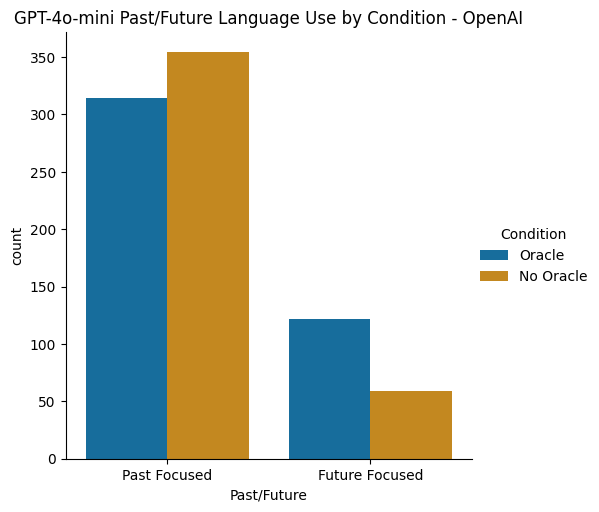

In [ ]:
# Combine data with condition labels
oracle_df = e_with_c_predictions.copy()
oracle_df["Condition"] = "Oracle"
no_oracle_df = e_no_c_predictions.copy()
no_oracle_df["Condition"] = "No Oracle"
combined_df = pd.concat([oracle_df, no_oracle_df])

# Create catplot
sns.catplot(
    data=combined_df,
    x="past_future_gpt",
    hue="Condition",
    kind="count",
    # palette={"Oracle": "blue", "No Oracle": "red"}
)


if model == "anthropic":
    plt.title("GPT-4o-mini Past/Future Language Use by Condition - Claude")
elif model == "openai":
    plt.title("GPT-4o-mini Past/Future Language Use by Condition - OpenAI")

plt.xlabel("Past/Future")
plt.xticks([0, 1], ["Past Focused", "Future Focused"])
plt.savefig("past_future_LLM.svg", dpi=300)
# plt.legend()

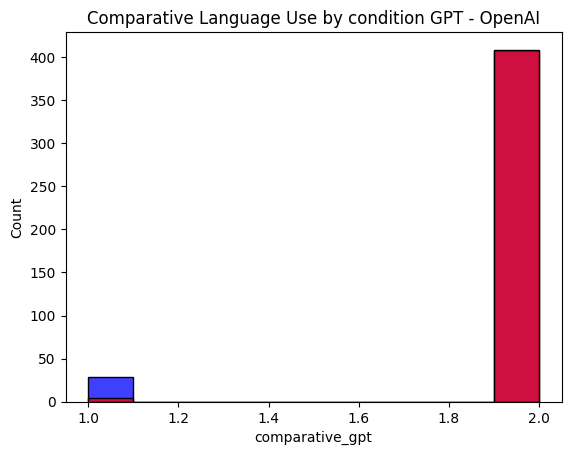

In [ ]:
model = "openai"
sns.histplot(liwc_oracle_openai["comparative_gpt"], color="blue")
sns.histplot(liwc_no_oracle_openai["comparative_gpt"], color="red")

if model == "anthropic":
    plt.title("Comparative Language Use by condition GPT - Claude")
elif model == "openai":
    plt.title("Comparative Language Use by condition GPT - OpenAI")

In [76]:
mannwhitneyu(
    liwc_oracle_anthropic["cleverness_gpt"].astype(int),
    liwc_no_oracle_anthropic["cleverness_gpt"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=106495.0, pvalue=3.852334152686572e-10)

In [77]:
mannwhitneyu(
    liwc_oracle_openai["cleverness_gpt"].astype(int),
    liwc_no_oracle_openai["cleverness_gpt"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=103144.5, pvalue=1.8538722698969993e-06)

In [138]:
for index, row in tqdm(df_no_oracle.iterrows(), total=len(df_no_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = perceptual_details_prompt + "\n" + explanation_claude
    prompt_gpt = perceptual_details_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_no_c_predictions_LLM.at[index, "perceptual_details_claude"] = pred_claude
    e_no_c_predictions_LLM.at[index, "perceptual_details_gpt"] = pred_gpt

100%|██████████| 413/413 [05:03<00:00,  1.36it/s]


In [139]:
for index, row in tqdm(df_oracle.iterrows(), total=len(df_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = perceptual_details_prompt + "\n" + explanation_claude
    prompt_gpt = perceptual_details_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_with_c_predictions_LLM.at[index, "perceptual_details_claude"] = pred_claude
    e_with_c_predictions_LLM.at[index, "perceptual_details_gpt"] = pred_gpt

100%|██████████| 436/436 [06:13<00:00,  1.17it/s]


In [140]:
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["perceptual_details_claude"] == "1")
    | (e_no_c_predictions_LLM["perceptual_details_claude"] == "2")
]
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["perceptual_details_gpt"] == "1")
    | (e_no_c_predictions_LLM["perceptual_details_gpt"] == "2")
]

e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["perceptual_details_claude"] == "1")
    | (e_with_c_predictions_LLM["perceptual_details_claude"] == "2")
]
e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["perceptual_details_gpt"] == "1")
    | (e_with_c_predictions_LLM["perceptual_details_gpt"] == "2")
]

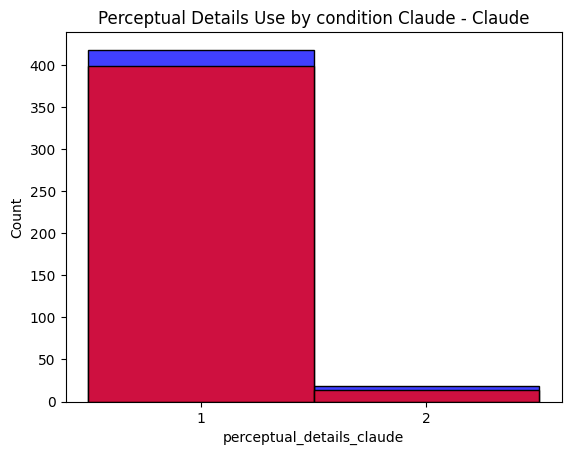

In [ ]:
sns.histplot(e_with_c_predictions_LLM["perceptual_details_claude"], color="blue")
sns.histplot(e_no_c_predictions_LLM["perceptual_details_claude"], color="red")

if model == "anthropic":
    plt.title("Perceptual Details Use by condition Claude - Claude")
elif model == "openai":
    plt.title("Perceptual Details Use by condition Claude - OpenAI")

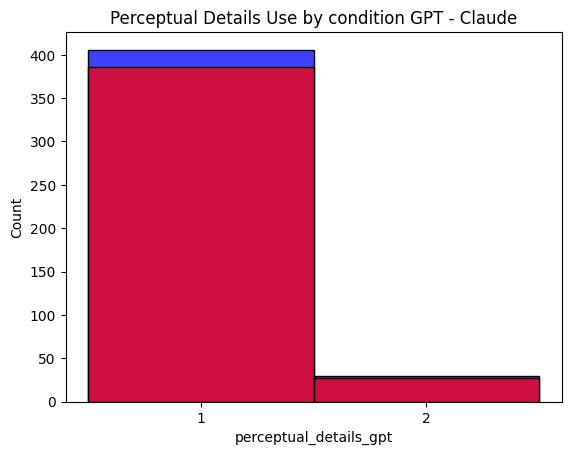

In [ ]:
sns.histplot(e_with_c_predictions_LLM["perceptual_details_gpt"], color="blue")
sns.histplot(e_no_c_predictions_LLM["perceptual_details_gpt"], color="red")

if model == "anthropic":
    plt.title("Perceptual Details Use by condition GPT - Claude")
elif model == "openai":
    plt.title("Perceptual Details Use by condition GPT - OpenAI")

In [143]:
mannwhitneyu(
    e_with_c_predictions_LLM["perceptual_details_claude"].astype(int),
    e_no_c_predictions_LLM["perceptual_details_claude"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=90699.0, pvalue=0.5727192069479148)

In [144]:
mannwhitneyu(
    e_with_c_predictions_LLM["perceptual_details_gpt"].astype(int),
    e_no_c_predictions_LLM["perceptual_details_gpt"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=90343.0, pvalue=0.8420433331179189)

In [145]:
for index, row in tqdm(df_no_oracle.iterrows(), total=len(df_no_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = causaual_analytical_prompt + "\n" + explanation_claude
    prompt_gpt = causaual_analytical_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_no_c_predictions_LLM.at[index, "causual_analytical_claude"] = pred_claude
    e_no_c_predictions_LLM.at[index, "causual_analytical_gpt"] = pred_gpt

100%|██████████| 413/413 [05:24<00:00,  1.27it/s]


In [146]:
for index, row in tqdm(df_oracle.iterrows(), total=len(df_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = causaual_analytical_prompt + "\n" + explanation_claude
    prompt_gpt = causaual_analytical_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_with_c_predictions_LLM.at[index, "causual_analytical_claude"] = pred_claude
    e_with_c_predictions_LLM.at[index, "causual_analytical_gpt"] = pred_gpt

100%|██████████| 436/436 [06:33<00:00,  1.11it/s]


In [147]:
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["causual_analytical_claude"] == "1")
    | (e_no_c_predictions_LLM["causual_analytical_claude"] == "2")
]
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["causual_analytical_gpt"] == "1")
    | (e_no_c_predictions_LLM["causual_analytical_gpt"] == "2")
]

e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["causual_analytical_claude"] == "1")
    | (e_with_c_predictions_LLM["causual_analytical_claude"] == "2")
]
e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["causual_analytical_gpt"] == "1")
    | (e_with_c_predictions_LLM["causual_analytical_gpt"] == "2")
]

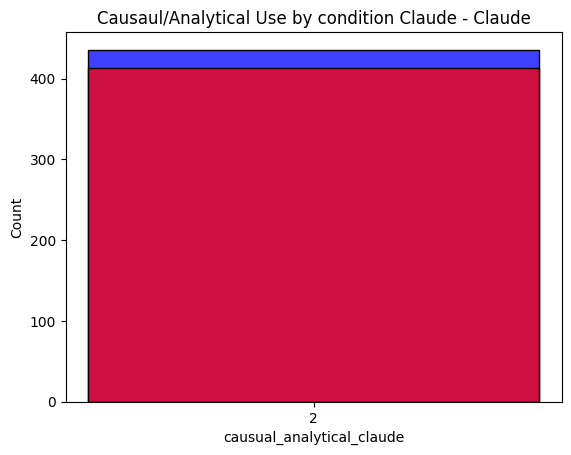

In [ ]:
sns.histplot(e_with_c_predictions_LLM["causual_analytical_claude"], color="blue")
sns.histplot(e_no_c_predictions_LLM["causual_analytical_claude"], color="red")

if model == "anthropic":
    plt.title("Causaul/Analytical Use by condition Claude - Claude")
elif model == "openai":
    plt.title("Causaul/Analytical Use by condition Claude - OpenAI")

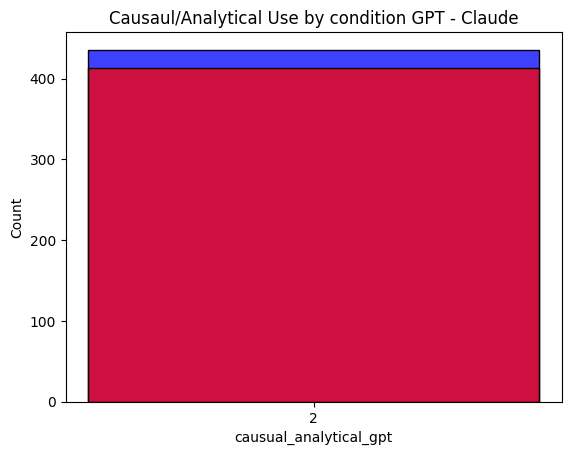

In [ ]:
sns.histplot(e_with_c_predictions_LLM["causual_analytical_gpt"], color="blue")
sns.histplot(e_no_c_predictions_LLM["causual_analytical_gpt"], color="red")

if model == "anthropic":
    plt.title("Causaul/Analytical Use by condition GPT - Claude")
elif model == "openai":
    plt.title("Causaul/Analytical Use by condition GPT - OpenAI")

In [151]:
mannwhitneyu(
    e_with_c_predictions_LLM["causual_analytical_claude"].astype(int),
    e_no_c_predictions_LLM["causual_analytical_claude"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=90034.0, pvalue=1.0)

In [150]:
mannwhitneyu(
    e_with_c_predictions_LLM["causual_analytical_gpt"].astype(int),
    e_no_c_predictions_LLM["causual_analytical_gpt"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=90034.0, pvalue=1.0)

In [152]:
for index, row in tqdm(df_no_oracle.iterrows(), total=len(df_no_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = comparative_prompt + "\n" + explanation_claude
    prompt_gpt = comparative_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_no_c_predictions_LLM.at[index, "comparative_claude"] = pred_claude
    e_no_c_predictions_LLM.at[index, "comparative_gpt"] = pred_gpt

100%|██████████| 413/413 [04:54<00:00,  1.40it/s]


In [153]:
for index, row in tqdm(df_oracle.iterrows(), total=len(df_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = comparative_prompt + "\n" + explanation_claude
    prompt_gpt = comparative_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_with_c_predictions_LLM.at[index, "comparative_claude"] = pred_claude
    e_with_c_predictions_LLM.at[index, "comparative_gpt"] = pred_gpt

100%|██████████| 436/436 [04:47<00:00,  1.52it/s]


In [154]:
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["comparative_claude"] == "1")
    | (e_no_c_predictions_LLM["comparative_claude"] == "2")
]
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["comparative_gpt"] == "1")
    | (e_no_c_predictions_LLM["comparative_gpt"] == "2")
]

e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["comparative_claude"] == "1")
    | (e_with_c_predictions_LLM["comparative_claude"] == "2")
]
e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["comparative_gpt"] == "1")
    | (e_with_c_predictions_LLM["comparative_gpt"] == "2")
]

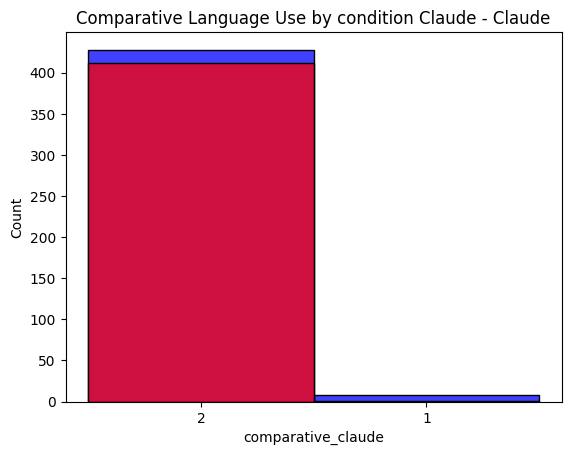

In [ ]:
sns.histplot(e_with_c_predictions_LLM["comparative_claude"], color="blue")
sns.histplot(e_no_c_predictions_LLM["comparative_claude"], color="red")
if model == "anthropic":
    plt.title("Comparative Language Use by condition Claude - Claude")
elif model == "openai":
    plt.title("Comparative Language Use by condition Claude - OpenAI")

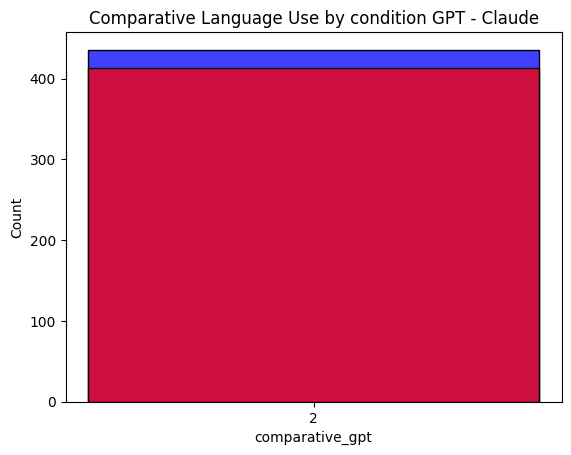

In [ ]:
sns.histplot(e_with_c_predictions_LLM["comparative_gpt"], color="blue")
sns.histplot(e_no_c_predictions_LLM["comparative_gpt"], color="red")

if model == "anthropic":
    plt.title("Comparative Language Use by condition GPT - Claude")
elif model == "openai":
    plt.title("Comparative Language Use by condition GPT - OpenAI")

In [157]:
mannwhitneyu(
    e_with_c_predictions_LLM["comparative_claude"].astype(int),
    e_no_c_predictions_LLM["comparative_claude"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=88600.0, pvalue=0.02364793069381179)

In [158]:
mannwhitneyu(
    e_with_c_predictions_LLM["comparative_gpt"].astype(int),
    e_no_c_predictions_LLM["comparative_gpt"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=90034.0, pvalue=1.0)

In [159]:
for index, row in tqdm(df_no_oracle.iterrows(), total=len(df_no_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = cleverness_prompt + "\n" + explanation_claude
    prompt_gpt = cleverness_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_no_c_predictions_LLM.at[index, "cleverness_claude"] = pred_claude
    e_no_c_predictions_LLM.at[index, "cleverness_gpt"] = pred_gpt

100%|██████████| 413/413 [04:58<00:00,  1.39it/s]


In [160]:
for index, row in tqdm(df_oracle.iterrows(), total=len(df_oracle)):
    explanation_claude = row["Claude_Explanation"]
    explanation_gpt = row["GPT4o_Explanation"]
    prompt_claude = cleverness_prompt + "\n" + explanation_claude
    prompt_gpt = cleverness_prompt + "\n" + explanation_gpt
    if model == "anthropic":
        message_claude = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
        )
        message_gpt = client.messages.create(
            model="claude-3-5-sonnet-20241022",
            max_tokens=1000,
            temperature=0,
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
        )
        pred_gpt = message_gpt.content[0].text
        pred_claude = message_claude.content[0].text
    elif model == "openai":
        message_claude = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_claude}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        message_gpt = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "user", "content": [{"type": "text", "text": prompt_gpt}]}
            ],
            response_format={"type": "text"},
            temperature=0,
            max_completion_tokens=2048,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
        )
        pred_claude = message_claude.choices[0].message.content
        pred_gpt = message_gpt.choices[0].message.content

    e_with_c_predictions_LLM.at[index, "cleverness_claude"] = pred_claude
    e_with_c_predictions_LLM.at[index, "cleverness_gpt"] = pred_gpt

  0%|          | 0/436 [00:00<?, ?it/s]

100%|██████████| 436/436 [04:56<00:00,  1.47it/s]


In [161]:
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["cleverness_claude"] == "1")
    | (e_no_c_predictions_LLM["cleverness_claude"] == "2")
]
e_no_c_predictions_LLM = e_no_c_predictions_LLM[
    (e_no_c_predictions_LLM["cleverness_gpt"] == "1")
    | (e_no_c_predictions_LLM["cleverness_gpt"] == "2")
]

e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["cleverness_claude"] == "1")
    | (e_with_c_predictions_LLM["cleverness_claude"] == "2")
]
e_with_c_predictions_LLM = e_with_c_predictions_LLM[
    (e_with_c_predictions_LLM["cleverness_gpt"] == "1")
    | (e_with_c_predictions_LLM["cleverness_gpt"] == "2")
]

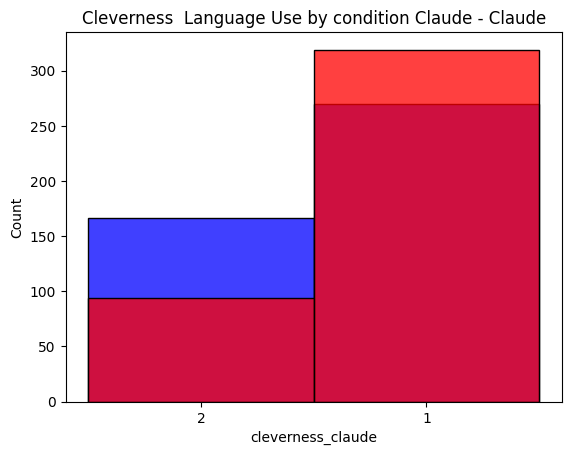

In [ ]:
sns.histplot(e_with_c_predictions_LLM["cleverness_claude"], color="blue")
sns.histplot(e_no_c_predictions_LLM["cleverness_claude"], color="red")

if model == "anthropic":
    plt.title("Cleverness  Language Use by condition Claude - Claude")
elif model == "openai":
    plt.title("Cleverness  Language Use by condition Claude - OpenAI")

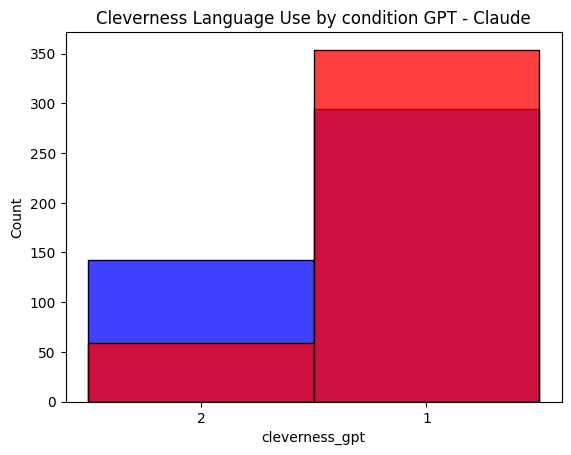

In [ ]:
sns.histplot(e_with_c_predictions_LLM["cleverness_gpt"], color="blue")
sns.histplot(e_no_c_predictions_LLM["cleverness_gpt"], color="red")

if model == "anthropic":
    plt.title("Cleverness Language Use by condition GPT - Claude")
elif model == "openai":
    plt.title("Cleverness Language Use by condition GPT - OpenAI")

In [164]:
mannwhitneyu(
    e_with_c_predictions_LLM["cleverness_claude"].astype(int),
    e_no_c_predictions_LLM["cleverness_claude"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=103821.0, pvalue=1.3297526659314403e-06)

In [165]:
mannwhitneyu(
    e_with_c_predictions_LLM["cleverness_gpt"].astype(int),
    e_no_c_predictions_LLM["cleverness_gpt"].astype(int),
    alternative="two-sided",
)

MannwhitneyuResult(statistic=106495.0, pvalue=3.852334152686572e-10)

In [166]:
if model == "openai":
    e_no_c_predictions_LLM.to_csv(
        "LIWC_no_oracle_predictions_LLM_OpenAI.csv", index=False
    )
    e_with_c_predictions_LLM.to_csv(
        "LIWC_oracle_predictions_LLM_OpenAI.csv", index=False
    )
elif model == "anthropic":
    e_no_c_predictions_LLM.to_csv(
        "LIWC_no_oracle_predictions_LLM_Anthropic.csv", index=False
    )
    e_with_c_predictions_LLM.to_csv(
        "LIWC_oracle_predictions_LLM_Anthropic.csv", index=False
    )